In [5]:
import os
import cv2
from numpy.random import f
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from PIL import Image
import imagehash
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score , classification_report
from collections import Counter
import albumentations as A
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from torch.utils.data import Dataset, DataLoader , WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from sklearn.metrics import confusion_matrix


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
dataset_path = "Data"
shoplifters_path = os.path.join(dataset_path,"shop lifters")
nonshoplifters_path = os.path.join(dataset_path,"non shop lifters")

print("Folders:", os.listdir(dataset_path))
print("Shoplifters videos:", len(os.listdir(shoplifters_path)))
print("Non-shoplifters videos:", len(os.listdir(nonshoplifters_path)))

Folders: ['non shop lifters', 'shop lifters']
Shoplifters videos: 301
Non-shoplifters videos: 295


In [ ]:
def video_hash(video_path, num_frames=20):

    cap = cv2.VideoCapture(video_path)

    hashes = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // num_frames, 1)

    for i in range(num_frames):

        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame)

        h = imagehash.phash(img)
        hashes.append(str(h))

    cap.release()

    return tuple(hashes)
    
## Try MD5

In [8]:
video_hashes = {}
duplicates = []

for root,_,files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".mp4"):

            path = os.path.join(root,file)

            h = video_hash(path)

            if h in video_hashes:
                duplicates.append((path,video_hashes[h]))
            else:
                video_hashes[h] = path

print("Number of duplicates:", len(duplicates))
duplicates[:5]

Number of duplicates: 0


[]

In [9]:
for dup in duplicates:
    os.remove(dup[0])

print("Duplicates removed")

Duplicates removed


In [10]:
video_paths = []
labels = []

classes = {
    "non shop lifters": 0,
    "shop lifters": 1
}

for class_name, label in classes.items():

    class_folder = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_folder):

        if file.endswith(".mp4"):

            path = os.path.join(class_folder, file)

            video_paths.append(path)
            labels.append(label)

print("Total videos:", len(video_paths))

Total videos: 596


In [11]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 417
Validation: 89
Test: 90


In [12]:
MAX_FRAMES = 16
IMG_SIZE = 96

def extract_frames(video_path):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // MAX_FRAMES, 1)

    frames = []

    for i in range(MAX_FRAMES):

        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frames.append(frame)

    cap.release()

    frames = np.array(frames)

    if len(frames) < MAX_FRAMES:

        padding = np.zeros((MAX_FRAMES-len(frames), IMG_SIZE, IMG_SIZE, 3))
        frames = np.concatenate((frames, padding))

    frames = frames / 255.0

    frames = np.transpose(frames, (3,0,1,2))  # C,T,H,W

    return frames

In [13]:
#transform = A.Compose([
    
#    A.HorizontalFlip(p=0.5),
#    A.RandomBrightnessContrast(p=0.3),
#    A.Rotate(limit=10,p=0.3)
#])

#def augment_video(frames):

#    aug_frames = []

#    for frame in frames:

#        augmented = transform(image=frame)['image']
#        aug_frames.append(augmented)

#    return np.array(aug_frames)

In [14]:
class VideoDataset(Dataset):

    def __init__(self, video_paths, labels):

        self.video_paths = video_paths
        self.labels = labels

    def __len__(self):

        return len(self.video_paths)

    def __getitem__(self, idx):

        video_path = self.video_paths[idx]

        frames = extract_frames(video_path)

        frames = torch.tensor(frames, dtype=torch.float32)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return frames, label

In [15]:
train_dataset = VideoDataset(train_paths, train_labels)
val_dataset = VideoDataset(val_paths , val_labels)
test_dataset = VideoDataset(test_paths, test_labels)

class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts

sample_weights = [class_weights[label] for label in train_labels]


train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(

    val_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

for X, y in train_loader:

    print("Batch shape:", X.shape)
    print("Labels shape:", y.shape)

    break

Batch shape: torch.Size([4, 3, 16, 96, 96])
Labels shape: torch.Size([4])


In [16]:
class CNN3D(nn.Module):

    def __init__(self):

        super(CNN3D, self).__init__()

        self.features = nn.Sequential(

            nn.Conv3d(3, 32, 3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d((1,2,2)),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(128, 256, 3, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool3d((1,1,1))
        )

        self.classifier = nn.Sequential(
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        x = self.classifier(x)

        return x

In [17]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

def train_model(model, train_loader, val_loader, epochs=10):

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=2e-5)

    criterion = nn.CrossEntropyLoss(weight=weights)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()

        running_loss = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for X, y in progress_bar:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            progress_bar.set_postfix(loss=running_loss/(progress_bar.n+1))

        train_loss = running_loss / len(train_loader)

        train_losses.append(train_loss)

        # ---------------- VALIDATION ----------------
        model.eval()

        val_running_loss = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():

            for X, y in val_loader:

                X = X.to(device)
                y = y.to(device)

                outputs = model(X)

                loss = criterion(outputs, y)

                val_running_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)

        val_losses.append(val_loss)

        precision = precision_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss:", train_loss)
        print(f"Val Loss:", val_loss)
        print(f"Val Precision:, {precision:.4f}")
        print(f"Val Recall:, {recall:.4f}")
        print(f"Val F1:, {f1:.4f}")
        

    return model, train_losses, val_losses

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score , classification_report
from tqdm import tqdm

def evaluate(model, test_loader):

    model = model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X, y in tqdm(test_loader, desc="Evaluating"):

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Precision:, {precision:.4f}")
    print(f"Recall:, {recall:.4f}")
    print(f"F1:, {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["Non-Shoplifter","Shoplifter"]))

    return precision, recall, f1

In [19]:
model_3dcnn = CNN3D()

model_3dcnn, train_loss_3d, val_loss_3d = train_model(
    model_3dcnn,
    train_loader,
    val_loader,
    epochs=5
)

evaluate(model_3dcnn, test_loader)

Epoch 1/5: 100%|██████████| 105/105 [02:41<00:00,  1.54s/it, loss=0.683]



Epoch 1
Train Loss: 0.6828802245003837
Val Loss: 0.6863664660764777
Val Precision:, 0.5301
Val Recall:, 0.9778
Val F1:, 0.6875


Epoch 2/5: 100%|██████████| 105/105 [02:44<00:00,  1.57s/it, loss=0.622]
c:\Users\saifk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Epoch 2
Train Loss: 0.6217242121696472
Val Loss: 0.6716158273427383
Val Precision:, 0.0000
Val Recall:, 0.0000
Val F1:, 0.0000


Epoch 3/5: 100%|██████████| 105/105 [02:42<00:00,  1.54s/it, loss=0.526]


...

Epoch 5/5: 100%|██████████| 105/105 [02:42<00:00,  1.54s/it, loss=0.384]



Epoch 5
Train Loss: 0.38362866909731
Val Loss: 0.4598361684576325
Val Precision:, 0.7500
Val Recall:, 1.0000
Val F1:, 0.8571


Evaluating: 100%|██████████| 23/23 [00:36<00:00,  1.58s/it]

Precision:, 0.8036
Recall:, 1.0000
F1:, 0.8911

Classification Report:

                precision    recall  f1-score   support

Non-Shoplifter       1.00      0.76      0.86        45
    Shoplifter       0.80      1.00      0.89        45

      accuracy                           0.88        90
     macro avg       0.90      0.88      0.88        90
  weighted avg       0.90      0.88      0.88        90



(0.8035714285714286, 1.0, 0.8910891089108911)

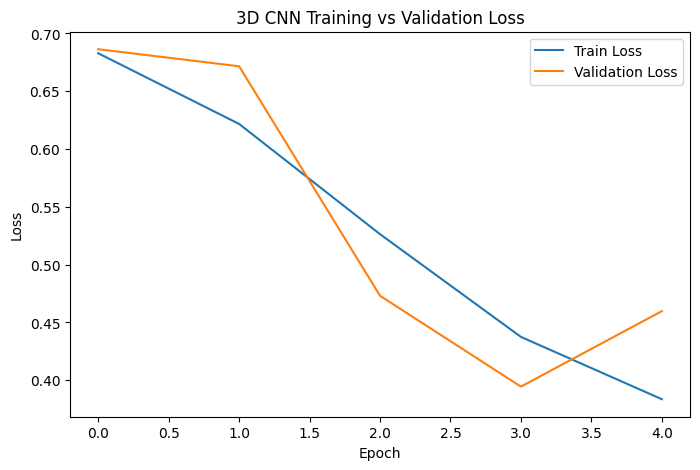

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_3d, label="Train Loss")
plt.plot(val_loss_3d, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("3D CNN Training vs Validation Loss")

plt.legend()

plt.show()

In [21]:
def evaluate_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X, y in tqdm(test_loader, desc="Evaluating"):

            X = X.to(device)

            outputs = model(X)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    return y_true, y_pred

In [22]:
def plot_three_confusion_matrices(y_true_3d, y_pred_3d):

    cm1 = confusion_matrix(y_true_3d, y_pred_3d)


    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    titles = ["3D CNN"]

    cms = [cm1]

    for ax, cm, title in zip(axes, cms, titles):

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="magma",
            ax=ax,
            xticklabels=["Non-Shoplifter", "Shoplifter"],
            yticklabels=["Non-Shoplifter", "Shoplifter"]
        )

        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

In [23]:
y_true_3d, y_pred_3d = evaluate_model(model_3dcnn, test_loader)

Evaluating: 100%|██████████| 23/23 [00:36<00:00,  1.58s/it]

Precision: 0.8035714285714286
Recall: 1.0
F1: 0.8910891089108911


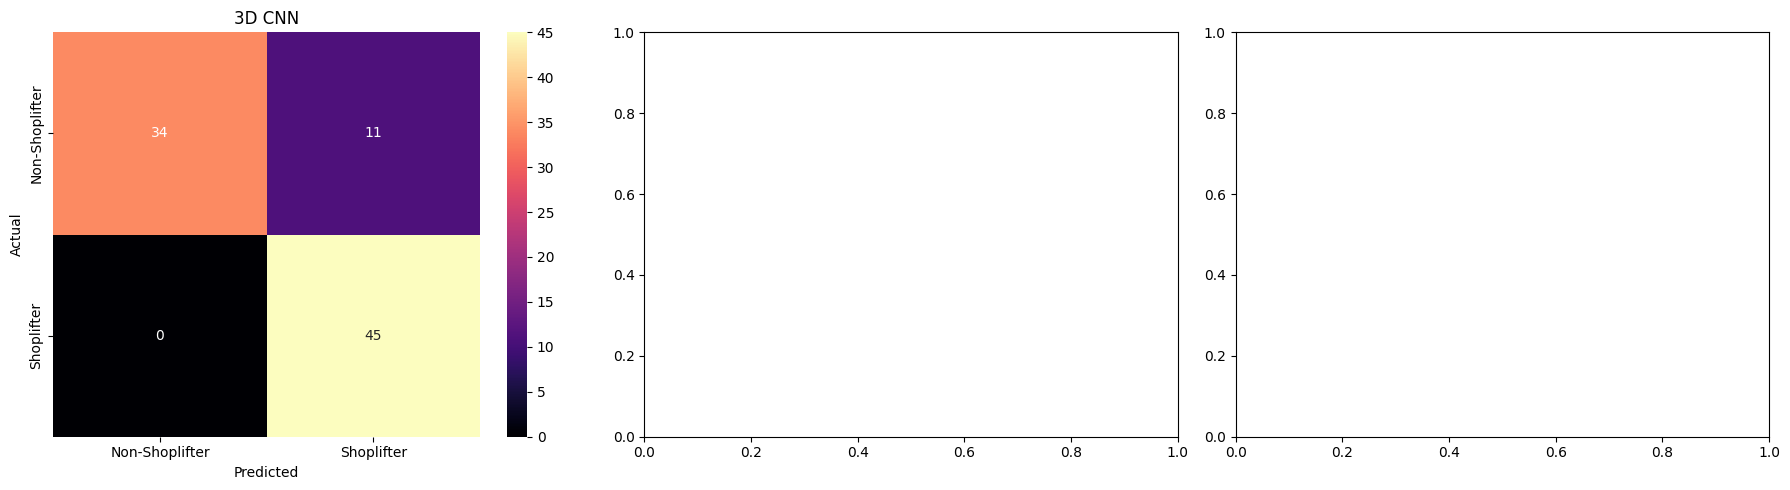

In [24]:
plot_three_confusion_matrices(y_true_3d, y_pred_3d)